# Task 3 — Generative AI Category Summaries

This notebook builds evidence-based buyer-guide drafts for the five Task 2 product categories. The local Hugging Face DistilBART route has been run on all five categories and its outputs are saved. An optional OpenAI API route remains separate; it is not needed for the local pretrained-model deliverable.

**Run from top to bottom.** Local data inspection and mock tests make no model API calls. The local transformer downloads its checkpoint on first use (about 1.2 GB), then runs inference on CPU or CUDA if available. OpenAI API steps remain explicitly opt-in and may incur charges.

**Verified status:** `outputs/task3_local_category_articles.md` and `outputs/task3_local_ai_drafts.csv` contain five locally generated DistilBART category guides. The separate `outputs/task3_category_articles.md` and `outputs/task3_ai_drafts.csv` files remain legacy drafts and are not verified live API results. The optional live OpenAI prompt comparison has not been run.

## What Task 3 does

For each cluster created in Task 2, the workflow calculates review counts, rating and sentiment statistics, the highest- and lowest-rated products, and a small selection of positive and negative review excerpts. Each top product and the lowest-rated product also gets its own sampled negative-review excerpts when available. The local BART model summarizes the review excerpts, while Python places those summaries alongside the factual product and category statistics in one Markdown guide per category.

The recommended local option is Hugging Face `sshleifer/distilbart-cnn-12-6`, a distilled BART CNN/DailyMail summarization checkpoint. It downloads model weights to the local Hugging Face cache and runs inference on this computer; no API key is required and the review evidence is not sent to an inference service. First use requires internet access and roughly 1.2 GB for checkpoint files; CPU generation can take several minutes. The small checkpoint is a summarizer, not a chat/instruction model. We therefore calculate rankings and statistics directly from the data and use the model only to summarize sampled review excerpts.

The optional hosted OpenAI route defaults to `gpt-4o-mini`; API use may incur charges. Its selected review excerpts are sent to OpenAI. That route is separate from the local DistilBART run.

Generated text is a **draft**, not verified truth. The local model is abstractive and can still distort review meaning. It summarizes product-specific negative excerpts; the notebook keeps numeric stats and product ranking data-derived and cautions against treating the lowest-rated product as automatically one to avoid. The local pretrained-model workflow is complete. The live prompt-variant experiment is an optional hosted OpenAI comparison and remains unrun; no OpenAI results or winning prompt should be claimed.

In [30]:
from pathlib import Path
import importlib
import inspect
import json
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown

# Find the repository even if Jupyter was opened from notebooks/ or the repo root.
working_path = Path.cwd().resolve()
ROOT = next(
    (path for path in (working_path, *working_path.parents)
     if (path / "src" / "task3_summarizer.py").is_file()),
    None,
)
if ROOT is None:
    raise FileNotFoundError(
        "Could not locate the repository. Open this notebook inside the project folder."
    )

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import src.task3_summarizer as task3_summarizer
task3_summarizer = importlib.reload(task3_summarizer)
_build_cluster_evidence = task3_summarizer._build_cluster_evidence
generate_category_articles = task3_summarizer.generate_category_articles

OUTPUT_DIR = ROOT / "outputs"
print(f"Repository: {ROOT}")
print(f"Outputs:    {OUTPUT_DIR}")

Repository: <project root>
Outputs:    outputs


## 1. Load and validate Task 2 results

Task 3 uses the saved Task 2 category profiles and review-to-cluster assignments. This means you do not need to rerun clustering to regenerate the guides. Reviews marked `cluster_id = -1` have no known product category and are intentionally excluded from category evidence.

In [31]:
PROFILE_PATH = OUTPUT_DIR / "task2_cluster_profiles.csv"
PRODUCT_PATH = OUTPUT_DIR / "task2_product_clusters.csv"
REVIEW_PATH = OUTPUT_DIR / "task2_review_clusters.csv"

for path in (PROFILE_PATH, PRODUCT_PATH, REVIEW_PATH):
    if not path.is_file():
        raise FileNotFoundError(
            f"Required Task 2 artifact is missing: {path}. Run Task 2 first."
        )

profiles = pd.read_csv(PROFILE_PATH)
products = pd.read_csv(PRODUCT_PATH)
reviews = pd.read_csv(REVIEW_PATH)

required_profile_columns = {"cluster_id", "cluster_name"}
required_product_columns = {"product_name", "cluster_id"}
required_review_columns = {
    "product_name", "review_text", "rating", "sentiment", "cluster_id"
}
for label, frame, required in (
    ("profiles", profiles, required_profile_columns),
    ("products", products, required_product_columns),
    ("reviews", reviews, required_review_columns),
):
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f"Task 2 {label} file is missing columns: {sorted(missing)}")

profiles["cluster_id"] = pd.to_numeric(profiles["cluster_id"], errors="raise").astype(int)
reviews["cluster_id"] = pd.to_numeric(reviews["cluster_id"], errors="raise").astype(int)
if profiles["cluster_id"].duplicated().any():
    raise ValueError("Cluster profiles contain duplicate cluster IDs.")

cluster_ids = set(profiles["cluster_id"])
review_cluster_ids = set(reviews.loc[reviews["cluster_id"] >= 0, "cluster_id"])
if not review_cluster_ids.issubset(cluster_ids):
    raise ValueError("Some assigned reviews refer to cluster IDs missing from profiles.")

named_reviews = reviews.loc[reviews["cluster_id"] >= 0].copy()
print(f"Categories: {len(profiles):,}")
print(f"Products: {len(products):,}")
print(f"Reviews in named categories: {len(named_reviews):,}")
print(f"Unclassified reviews excluded: {(reviews['cluster_id'] < 0).sum():,}")

Categories: 5
Products: 40
Reviews in named categories: 27,866
Unclassified reviews excluded: 6,759


## 2. Inspect category evidence

Before calling an LLM, check that the categories and review statistics look reasonable. The mean rating and sentiment proportions below are calculated from the assigned review rows, not generated by the model.

In [32]:
category_summary = (
    named_reviews.groupby(["cluster_id", "cluster_name"], as_index=False)
    .agg(
        review_count=("review_text", "size"),
        product_count=("product_name", "nunique"),
        mean_rating=("rating", "mean"),
        negative_share=("sentiment", lambda values: (values == "negative").mean()),
        positive_share=("sentiment", lambda values: (values == "positive").mean()),
    )
    .sort_values("cluster_id")
)
category_summary["mean_rating"] = category_summary["mean_rating"].round(2)
category_summary["negative_share"] = (100 * category_summary["negative_share"]).round(2)
category_summary["positive_share"] = (100 * category_summary["positive_share"]).round(2)
display(category_summary.rename(columns={
    "negative_share": "negative (%)",
    "positive_share": "positive (%)",
}))

,cluster_id,cluster_name,review_count,product_count,mean_rating,negative (%),positive (%)
0,0,Fire Tablets,14649,8,4.49,2.81,91.57
1,1,Kindle E-readers,3894,7,4.75,1.13,96.82
2,2,"Echo, Audio & Related Products",3916,13,4.64,1.99,94.13
3,3,Fire TV & Streaming Devices,2543,7,4.65,1.57,94.89
4,4,Fire Kids & Family Tablets,2864,5,4.54,3.21,91.79


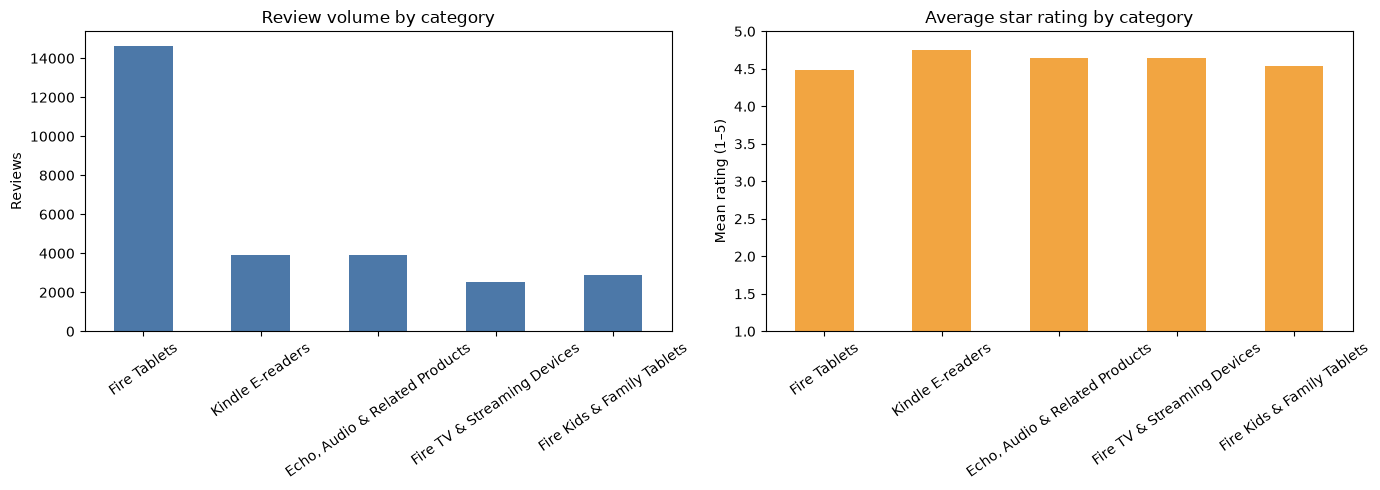

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
category_summary.plot(
    x="cluster_name", y="review_count", kind="bar", ax=axes[0],
    color="#4c78a8", legend=False,
)
axes[0].set_title("Review volume by category")
axes[0].set_xlabel("")
axes[0].set_ylabel("Reviews")
axes[0].tick_params(axis="x", rotation=35)

category_summary.plot(
    x="cluster_name", y="mean_rating", kind="bar", ax=axes[1],
    color="#f2a541", legend=False,
)
axes[1].set_title("Average star rating by category")
axes[1].set_xlabel("")
axes[1].set_ylabel("Mean rating (1–5)")
axes[1].set_ylim(1, 5)
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

## 3. Build one evidence brief

The shared helper in `src/task3_summarizer.py` creates a compact, reproducible evidence object for one category. It limits the review excerpts sent to the model and records the product/rating statistics so the generated summary can be checked.

In [34]:
example_profile = profiles.sort_values("cluster_id").iloc[0]
example_cluster_id = int(example_profile["cluster_id"])
example_evidence = _build_cluster_evidence(
    example_cluster_id,
    example_profile,
    named_reviews,
)
for product in example_evidence["highest_rated_products"]:
    assert all(
        item["product"] == product["name"]
        for item in product["negative_review_examples"]
    )
if example_evidence["lowest_rated_product"] is not None:
    worst = example_evidence["lowest_rated_product"]
    assert all(
        item["product"] == worst["name"]
        for item in worst["negative_review_examples"]
    )
print(f"Evidence brief for cluster {example_cluster_id}: {example_evidence['cluster_name']}\n")
print(json.dumps(example_evidence, indent=2, ensure_ascii=False))

Evidence brief for cluster 0: Fire Tablets

{
  "cluster_name": "Fire Tablets",
  "review_count": 14649,
  "product_count": 8,
  "mean_rating": 4.49,
  "negative_share": 0.0281,
  "positive_share": 0.9157,
  "highest_rated_products": [
    {
      "name": "Fire HD 8 Tablet with Alexa, 8 HD Display, 32 GB, Tangerine - with Special Offers",
      "mean_rating": 4.86,
      "review_count": 14,
      "negative_review_examples": []
    },
    {
      "name": "Amazon Fire Hd 10 Tablet, Wi-Fi, 16 Gb, Special Offers - Silver Aluminum",
      "mean_rating": 4.77,
      "review_count": 128,
      "negative_review_examples": [
        {
          "product": "Amazon Fire Hd 10 Tablet, Wi-Fi, 16 Gb, Special Offers - Silver Aluminum",
          "rating": "2.0",
          "review": "a wonderfully designed device but its use is fairly limited i bought it primarily to use as a smart home control device however although it allows you to turn on and off lights you cannot add timers to the control instruc

### See the exact production code

The following cell displays the shared generator used by both this notebook and `python run_project.py --task3-only`. The same implementation supplies the model instructions and writes the final files, so the walkthrough does not maintain a separate prompt implementation.

In [35]:
evidence_source = inspect.getsource(_build_cluster_evidence)
generator_source = inspect.getsource(generate_category_articles)
display(Markdown("### Evidence builder in `src/task3_summarizer.py`\n\n```python\n" + evidence_source + "\n```"))
display(Markdown("### API generation and output writer in `src/task3_summarizer.py`\n\n```python\n" + generator_source + "\n```"))

### Evidence builder in `src/task3_summarizer.py`

```python
def _build_cluster_evidence(
    cluster_id: int,
    cluster: pd.Series,
    reviews: pd.DataFrame,
) -> dict[str, Any]:
    cluster_reviews = reviews.loc[reviews["cluster_id"] == cluster_id].copy()
    if cluster_reviews.empty:
        raise ValueError(f"Cluster {cluster_id} has no assigned reviews.")

    products = (
        cluster_reviews.groupby("product_name")
        .agg(
            review_count=("review_text", "size"),
            mean_rating=("rating", "mean"),
            negative_share=("sentiment", lambda values: (values == "negative").mean()),
        )
        .reset_index()
    )
    established_products = products.loc[products["review_count"] >= 5]
    comparison_pool = established_products if not established_products.empty else products
    top_products = comparison_pool.sort_values(
        ["mean_rating", "review_count"], ascending=[False, False]
    ).head(3)
    lowest_rated = comparison_pool.sort_values(
        ["mean_rating", "review_count"], ascending=[True, False]
    ).head(1)

    def select_examples(sentiment: str, count: int) -> pd.DataFrame:
        examples = (
            cluster_reviews.loc[cluster_reviews["sentiment"] == sentiment]
            .drop_duplicates("review_text")
        )
        if examples.empty:
            return examples
        return examples.sample(n=min(count, len(examples)), random_state=42).sort_index()

    negative_examples = select_examples("negative", 5)
    positive_examples = select_examples("positive", 3)

    def product_complaints(product_name: str) -> list[dict[str, str]]:
        product_reviews = cluster_reviews.loc[
            (cluster_reviews["product_name"] == product_name)
            & (cluster_reviews["sentiment"] == "negative")
        ]
        return format_examples(
            product_reviews.drop_duplicates("review_text")
            .sample(
                n=min(3, product_reviews["review_text"].nunique()),
                random_state=42,
            )
            .sort_index()
        )

    def format_examples(examples: pd.DataFrame) -> list[dict[str, str]]:
        def redact_excerpt(text: str) -> str:
            excerpt = text[:500]
            excerpt = re.sub(
                r"\bmy name is\s+[\w'-]+(?:\s+[\w'-]+){0,2}",
                "my name is [redacted]",
                excerpt,
                flags=re.IGNORECASE,
            )
            excerpt = re.sub(
                r"\b[A-Z0-9._%+-]+@[A-Z0-9.-]+\.[A-Z]{2,}\b",
                "[redacted email]",
                excerpt,
                flags=re.IGNORECASE,
            )
            excerpt = re.sub(
                r"https?://\S+|www\.\S+",
                "[redacted link]",
                excerpt,
                flags=re.IGNORECASE,
            )
            excerpt = re.sub(
                r"(?<!\w)\+?\d[\d().\-\s]{7,}\d(?!\w)",
                "[redacted phone]",
                excerpt,
            )
            tail_start = max(0, len(excerpt) - 100)
            closing = re.search(
                r"\b(?:thank you|thanks|regards|sincerely)\b",
                excerpt[tail_start:],
                flags=re.IGNORECASE,
            )
            if closing:
                excerpt = excerpt[: tail_start + closing.start()].rstrip()
            return excerpt

        return [
            {
                "product": str(row.product_name),
                "rating": str(row.rating),
                "review": redact_excerpt(str(row.review_text)),
            }
            for row in examples.itertuples(index=False)
        ]

    return {
        "cluster_name": str(cluster["cluster_name"]),
        "review_count": int(cluster_reviews.shape[0]),
        "product_count": int(products.shape[0]),
        "mean_rating": round(float(cluster_reviews["rating"].mean()), 2),
        "negative_share": round(
            float((cluster_reviews["sentiment"] == "negative").mean()), 4
        ),
        "positive_share": round(
            float((cluster_reviews["sentiment"] == "positive").mean()), 4
        ),
        "highest_rated_products": [
            {
                "name": str(row.product_name),
                "mean_rating": round(float(row.mean_rating), 2),
                "review_count": int(row.review_count),
                "negative_review_examples": product_complaints(
                    str(row.product_name)
                ),
            }
            for row in top_products.itertuples(index=False)
        ],
        "lowest_rated_product": (
            {
                "name": str(lowest_rated.iloc[0]["product_name"]),
                "mean_rating": round(float(lowest_rated.iloc[0]["mean_rating"]), 2),
                "review_count": int(lowest_rated.iloc[0]["review_count"]),
                "negative_review_examples": product_complaints(
                    str(lowest_rated.iloc[0]["product_name"])
                ),
            }
            if not lowest_rated.empty
            else None
        ),
        "negative_review_examples": format_examples(negative_examples),
        "positive_review_examples": format_examples(positive_examples),
    }

```

### API generation and output writer in `src/task3_summarizer.py`

```python
def generate_category_articles(
    cluster_df: pd.DataFrame,
    reviews: pd.DataFrame,
    *,
    api_key: str | None = None,
    model: str | None = None,
    client: Any | None = None,
    output_dir: Path | None = None,
    prompt_variant: str = "structured_buyer_guide",
) -> tuple[str, pd.DataFrame]:
    """Generate one evidence-grounded article per product cluster using OpenAI."""
    api_key = api_key or os.getenv("OPENAI_API_KEY")
    if not api_key and client is None:
        raise RuntimeError(
            "Task 3 needs an OpenAI API key. Set OPENAI_API_KEY in your environment "
            "and rerun the pipeline."
        )

    model = model or os.getenv("OPENAI_MODEL", "gpt-4o-mini")
    build_system_prompt(prompt_variant)
    if client is None:
        client = OpenAI(api_key=api_key)
    output_dir = OUTPUT_DIR if output_dir is None else Path(output_dir)

    required_cluster_columns = {"cluster_id", "cluster_name"}
    missing_cluster_columns = required_cluster_columns.difference(cluster_df.columns)
    if missing_cluster_columns:
        raise ValueError(
            "Task 3 cluster profiles are missing required columns: "
            f"{sorted(missing_cluster_columns)}"
        )
    if cluster_df.empty:
        raise ValueError("Task 3 has no cluster profiles to summarize.")
    if cluster_df["cluster_id"].duplicated().any():
        raise ValueError("Task 3 cluster profiles contain duplicate cluster IDs.")

    required_columns = {
        "cluster_id",
        "product_name",
        "review_text",
        "rating",
        "sentiment",
    }
    missing = required_columns.difference(reviews.columns)
    if missing:
        raise ValueError(f"Task 3 review data is missing required columns: {sorted(missing)}")

    generated_at = datetime.now(timezone.utc).isoformat()
    sections = [
        "# Customer Review Guides by Product Cluster\n\n",
        "> AI-generated drafts based on the review evidence shown for each cluster. "
        "Review and verify before publication.\n\n",
        f"> Model: `{model}`  \n> Generated (UTC): `{generated_at}`\n\n",
    ]
    draft_rows = []

    for _, cluster in cluster_df.iterrows():
        cluster_id = int(cluster["cluster_id"])
        evidence = _build_cluster_evidence(cluster_id, cluster, reviews)
        try:
            article, response = generate_article_from_evidence(
                evidence,
                client=client,
                model=model,
                prompt_variant=prompt_variant,
            )
        except APIError as exc:
            raise RuntimeError(
                f"OpenAI API request failed for cluster {cluster_id} "
                f"({evidence['cluster_name']}) using model {model}: {exc}"
            ) from exc

        sections.append(f"## {evidence['cluster_name']}\n\n{article}\n\n")
        usage = getattr(response, "usage", None)
        draft_rows.append(
            {
                "cluster_id": cluster_id,
                "cluster_name": evidence["cluster_name"],
                "model": model,
                "prompt_variant": prompt_variant,
                "generated_at_utc": generated_at,
                "review_count": evidence["review_count"],
                "product_count": evidence["product_count"],
                "mean_rating": evidence["mean_rating"],
                "negative_share": evidence["negative_share"],
                "positive_share": evidence["positive_share"],
                "api_response_id": getattr(response, "id", None),
                "prompt_tokens": getattr(usage, "prompt_tokens", None),
                "completion_tokens": getattr(usage, "completion_tokens", None),
                "article": article,
            }
        )

    article_text = "".join(sections)
    output_dir.mkdir(parents=True, exist_ok=True)
    (output_dir / "task3_category_articles.md").write_text(
        article_text, encoding="utf-8"
    )
    drafts = pd.DataFrame(draft_rows)
    drafts.to_csv(output_dir / "task3_ai_drafts.csv", index=False)
    return article_text, drafts

```

## 4. Test the workflow without a key or API call

This mock client checks the shared generation and file-writing path while routing output to a temporary directory. It does **not** contact OpenAI and does **not** replace the files in `outputs/`. The resulting text is explicitly a fake test response, not a Task 3 result.

In [36]:
from tempfile import TemporaryDirectory
from types import SimpleNamespace

class FakeCompletions:
    def __init__(self):
        self.calls = []

    def create(self, **kwargs):
        self.calls.append(kwargs)
        return SimpleNamespace(
            id=f"mock-response-{len(self.calls)}",
            choices=[SimpleNamespace(message=SimpleNamespace(
                content="Mock-only text for verifying the notebook workflow."
            ))],
            usage=SimpleNamespace(prompt_tokens=10, completion_tokens=8),
        )

fake_completions = FakeCompletions()
fake_client = SimpleNamespace(
    chat=SimpleNamespace(completions=fake_completions)
)

with TemporaryDirectory(prefix="task3_mock_") as temp_dir:
    mock_article, mock_drafts = generate_category_articles(
        profiles,
        named_reviews,
        client=fake_client,
        model="mock-model-not-for-publication",
        output_dir=Path(temp_dir),
    )
    assert len(fake_completions.calls) == len(profiles)
    assert len(mock_drafts) == len(profiles)
    assert set(mock_drafts["cluster_name"]) == set(profiles["cluster_name"])
    assert (Path(temp_dir) / "task3_category_articles.md").is_file()
    assert (Path(temp_dir) / "task3_ai_drafts.csv").is_file()
    variant_articles = []
    for variant_name in task3_summarizer.PROMPT_VARIANTS:
        variant_article, _ = task3_summarizer.generate_article_from_evidence(
            example_evidence,
            client=fake_client,
            model="mock-model-not-for-publication",
            prompt_variant=variant_name,
        )
        variant_articles.append(variant_article)
    variant_system_prompts = [
        call["messages"][0]["content"] for call in fake_completions.calls[-3:]
    ]
    assert len(set(variant_system_prompts)) == 3
    assert len(variant_articles) == 3
    print("Mock test passed: five category requests plus three distinct prompt variants; no live API; temporary outputs only.")
    display(mock_drafts[["cluster_id", "cluster_name", "model", "api_response_id"]])

Mock test passed: five category requests plus three distinct prompt variants; no live API; temporary outputs only.


,cluster_id,cluster_name,model,api_response_id
0,0,Fire Tablets,mock-model-not-for-publication,mock-response-1
1,1,Kindle E-readers,mock-model-not-for-publication,mock-response-2
2,2,"Echo, Audio & Related Products",mock-model-not-for-publication,mock-response-3
3,3,Fire TV & Streaming Devices,mock-model-not-for-publication,mock-response-4
4,4,Fire Kids & Family Tablets,mock-model-not-for-publication,mock-response-5


## 5. Optional hosted-API prompt experiment (not run)

We defined three prompt variants that share factuality and safety rules but organize the buyer guide differently: `structured_buyer_guide`, `evidence_first`, and `concise_editorial`. The experiment sends the **same representative category evidence** to the same model once per variant (three API requests total). It does not regenerate all categories or replace final Task 3 files.

Set `RUN_PROMPT_EXPERIMENT = True` in the next cell only when ready to make those calls. Compare the drafts using the rubric: evidence accuracy, product-specific complaint grounding, useful product comparison, appropriate uncertainty, and readability. Check claims against the evidence; do not select a prompt on style alone. The ratings table is an evaluation aid, not an automatic quality score. After a live run, the three drafts and API provenance are saved to `outputs/task3_prompt_experiment.csv`.

In [37]:
# Set True to make three live, potentially billable requests using one category.
RUN_PROMPT_EXPERIMENT = False
prompt_experiment_results = []

if RUN_PROMPT_EXPERIMENT:
    from getpass import getpass
    from openai import OpenAI

    experiment_key = os.getenv("OPENAI_API_KEY")
    if not experiment_key:
        experiment_key = getpass("OpenAI API key (input hidden): ").strip()
    if not experiment_key:
        raise RuntimeError("No API key was provided; prompt experiment cancelled.")

    experiment_model = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
    experiment_client = OpenAI(api_key=experiment_key)
    del experiment_key

    for variant_name in task3_summarizer.PROMPT_VARIANTS:
        variant_article, variant_response = task3_summarizer.generate_article_from_evidence(
            example_evidence,
            client=experiment_client,
            model=experiment_model,
            prompt_variant=variant_name,
        )
        prompt_experiment_results.append({
            "prompt_variant": variant_name,
            "model": experiment_model,
            "api_response_id": getattr(variant_response, "id", None),
            "generated_at_utc": pd.Timestamp.now(tz="UTC").isoformat(),
            "prompt_tokens": getattr(getattr(variant_response, "usage", None), "prompt_tokens", None),
            "completion_tokens": getattr(getattr(variant_response, "usage", None), "completion_tokens", None),
            "article": variant_article,
        })

    prompt_experiment_df = pd.DataFrame(prompt_experiment_results)
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    prompt_experiment_path = OUTPUT_DIR / "task3_prompt_experiment.csv"
    prompt_experiment_df.to_csv(prompt_experiment_path, index=False)
    print(f"Saved three live prompt drafts and provenance to {prompt_experiment_path}")
    for row in prompt_experiment_results:
        display(Markdown(f"### {row['prompt_variant']}\n\n{row['article']}"))
else:
    print("Prompt experiment is off; no OpenAI requests were made.")

Prompt experiment is off; no OpenAI requests were made.


In [38]:
prompt_rubric = pd.DataFrame({
    "prompt_variant": list(task3_summarizer.PROMPT_VARIANTS),
    "evidence_accuracy_1_to_5": [None] * len(task3_summarizer.PROMPT_VARIANTS),
    "product_complaints_grounded_1_to_5": [None] * len(task3_summarizer.PROMPT_VARIANTS),
    "useful_comparison_1_to_5": [None] * len(task3_summarizer.PROMPT_VARIANTS),
    "uncertainty_handled_1_to_5": [None] * len(task3_summarizer.PROMPT_VARIANTS),
    "readability_1_to_5": [None] * len(task3_summarizer.PROMPT_VARIANTS),
    "notes": [""] * len(task3_summarizer.PROMPT_VARIANTS),
})
display(prompt_rubric)
print("Fill the scores and notes after inspecting the live drafts above.")

,prompt_variant,evidence_accuracy_1_to_5,product_complaints_grounded_1_to_5,useful_comparison_1_to_5,uncertainty_handled_1_to_5,readability_1_to_5,notes
0,structured_buyer_guide,None,None,None,None,None,
1,evidence_first,None,None,None,None,None,
2,concise_editorial,None,None,None,None,None,


Fill the scores and notes after inspecting the live drafts above.


## 6. Provide an API key safely (live generation is optional)

An OpenAI API key is required for real generation. Create/manage one in the [OpenAI API keys dashboard](https://platform.openai.com/api-keys) and keep it private. API billing is separate from a ChatGPT subscription. **Never paste it into a notebook code cell, commit it, or include it in screenshots.**

The live cell below prompts with `getpass` if `OPENAI_API_KEY` is not already set. The key is not echoed and is held only in this kernel's memory. Alternatively, set `OPENAI_API_KEY` in the environment before starting Jupyter. `OPENAI_MODEL` is optional; the default is `gpt-4o-mini`.

The full live-generation cell is disabled by default. Set `RUN_LIVE_API = True` only when ready to make five API requests. A successful run replaces the two Task 3 output files with new results and provenance metadata. If a request fails, the run reports the cluster and error instead of marking mock text as a real result. After evaluating prompt variants above, set `SELECTED_PROMPT_VARIANT` in the live cell to the variant you chose.

In [28]:
# Change to True only when you intend to make real, potentially billable API calls.
RUN_LIVE_API = False
live_article = None
live_drafts = None

if not RUN_LIVE_API:
    print("Live API generation is off. Set RUN_LIVE_API = True to continue.")
else:
    from getpass import getpass

    api_key = os.getenv("OPENAI_API_KEY")
    if not api_key:
        api_key = getpass("OpenAI API key (input hidden): ").strip()
    if not api_key:
        raise RuntimeError("No API key was provided; live generation was cancelled.")

    model_name = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
    print(f"Generating {len(profiles)} category guides with {model_name}.")
    print("The selected review excerpts will be sent to OpenAI.")
    SELECTED_PROMPT_VARIANT = "structured_buyer_guide"  # Replace after evaluating the prompt experiment.
    live_article, live_drafts = generate_category_articles(
        profiles,
        named_reviews,
        api_key=api_key,
        model=model_name,
        prompt_variant=SELECTED_PROMPT_VARIANT,
    )
    del api_key
    print("Live generation completed and Task 3 outputs were saved.")

Live API generation is off. Set RUN_LIVE_API = True to continue.


## 7. Inspect and verify fresh live outputs

This check runs only after a successful live API call in this kernel. Confirm the category names, evidence counts, model and generated articles. Then fact-check claims—especially product comparisons and complaint statements—against the original evidence before using or publishing them.

In [29]:
if live_drafts is None:
    print("No live outputs were generated in this notebook session.")
    print("The existing Task 3 files remain unverified until the live cell succeeds.")
else:
    article_path = OUTPUT_DIR / "task3_category_articles.md"
    drafts_path = OUTPUT_DIR / "task3_ai_drafts.csv"
    saved_drafts = pd.read_csv(drafts_path)
    required_output_columns = {
        "cluster_id", "cluster_name", "model", "generated_at_utc",
        "review_count", "product_count", "mean_rating", "article",
    }
    missing_output_columns = required_output_columns.difference(saved_drafts.columns)
    if missing_output_columns:
        raise ValueError(f"Generated CSV is missing columns: {sorted(missing_output_columns)}")
    if len(saved_drafts) != len(profiles) or saved_drafts["article"].isna().any():
        raise ValueError("Generated CSV does not contain one non-empty article per category.")

    print(f"Markdown: {article_path}")
    print(f"CSV:      {drafts_path}")
    display(saved_drafts[[
        "cluster_name", "model", "generated_at_utc", "review_count",
        "product_count", "mean_rating", "prompt_tokens", "completion_tokens",
    ]])
    display(Markdown(article_path.read_text(encoding="utf-8")))

No live outputs were generated in this notebook session.
The existing Task 3 files remain unverified until the live cell succeeds.


## 8. Generate category articles with local DistilBART

This is the local pretrained-transformer route. It does not require an API key. Install dependencies from `requirements.txt`, select the project `.venv-5` Python environment as the notebook kernel, and run this cell. On first use Hugging Face downloads `sshleifer/distilbart-cnn-12-6` into the local cache; later runs reuse that checkpoint. The helper summarizes sampled positive/negative excerpts and selected-product complaints in batches, and leaves all counts, ratings, and product ranking to the source data.

The generated local files are separate from the older hosted-API outputs: `outputs/task3_local_category_articles.md` and `outputs/task3_local_ai_drafts.csv`. This cell is intentionally enabled for the requested local run; set `RUN_LOCAL_MODEL = False` to skip inference after the model is cached.

In [ ]:
from src.task3_local_summarizer import (
    DEFAULT_MODEL as LOCAL_MODEL_NAME,
    generate_local_category_articles,
)

RUN_LOCAL_MODEL = True
local_article = None
local_drafts = None

if RUN_LOCAL_MODEL:
    print(f"Loading local model: {LOCAL_MODEL_NAME}")
    print("First run downloads model files; inference runs on CPU unless CUDA is available.")
    local_article, local_drafts = generate_local_category_articles(
        profiles,
        named_reviews,
        model_name=LOCAL_MODEL_NAME,
        output_dir=OUTPUT_DIR,
        batch_size=2,
    )
    print(f"Generated local drafts for {len(local_drafts)} categories.")
else:
    print("Local transformer generation skipped.")

In [ ]:
if local_drafts is None:
    print("No local-model articles were generated in this session.")
else:
    local_md_path = OUTPUT_DIR / "task3_local_category_articles.md"
    local_csv_path = OUTPUT_DIR / "task3_local_ai_drafts.csv"
    saved_local_drafts = pd.read_csv(local_csv_path)
    assert len(saved_local_drafts) == len(profiles)
    assert saved_local_drafts["cluster_name"].tolist() == profiles.sort_values("cluster_id")["cluster_name"].tolist()
    assert saved_local_drafts["article"].str.strip().ne("").all()
    assert set(saved_local_drafts["inference"]) == {"local"}
    print(f"Markdown: {local_md_path}")
    print(f"CSV:      {local_csv_path}")
    display(saved_local_drafts[[
        "cluster_name", "model", "inference", "review_count", "product_count", "mean_rating"
    ]])
    display(Markdown(local_md_path.read_text(encoding="utf-8")))

## What to report for Task 3

- The local pretrained model used is Hugging Face `sshleifer/distilbart-cnn-12-6` (DistilBART CNN/DailyMail), loaded with `transformers` and PyTorch. It was run on CPU for all five categories; the output CSV records the model and `inference=local` provenance.
- For each of the five Task 2 categories, the model summarizes positive and negative review samples and product-specific negative review examples. Product ranks and all review/rating statistics are computed directly from the dataset.
- Local artifacts: `outputs/task3_local_category_articles.md` and `outputs/task3_local_ai_drafts.csv`. They record model name, inference source, timestamp, and evidence statistics.
- DistilBART is abstractive and can change or add details; validate every generated complaint summary against the source reviews. No live model has been fine-tuned for this task.
- The local DistilBART category-guide workflow is complete; the saved files are actual local-model inference, not mock responses. Check each summary against source reviews because abstractive summaries can alter details.
- The separate hosted OpenAI route and its three live prompt variants are optional alternatives. No live OpenAI comparison was made, and no API prompt was selected as best.

The local model implementation is `src/task3_local_summarizer.py`. To rerun its generation from a Python session, load the Task 2 cluster profiles and review assignments and call `generate_local_category_articles(profiles, named_reviews)`. The OpenAI API implementation remains in `src/task3_summarizer.py`.